<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/HC_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [6]:
data.feature_names


array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

Tamaño del dataset: (569, 30)


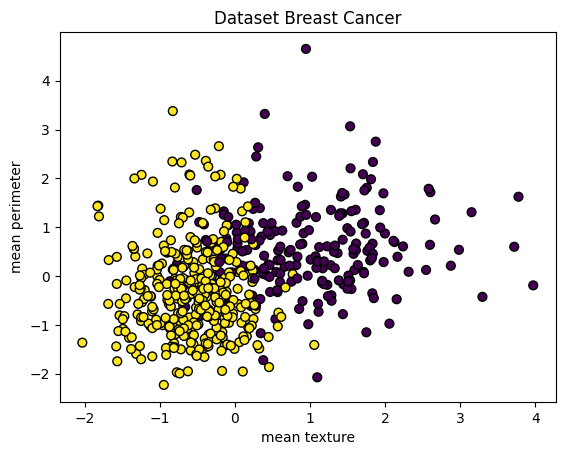

In [11]:
# Cargamos el dataset de Breast Cancer
data = load_breast_cancer()
X = data.data
y = data.target

# El agrupamiento jerárquico es sensible a las escalas, por lo que estandarizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

features = data.feature_names

print(f"Tamaño del dataset: {X_scaled.shape}")

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap="viridis", edgecolor="k", s=40)
plt.xlabel(features[1])
plt.ylabel(features[2])
plt.title("Dataset Breast Cancer")
plt.show()

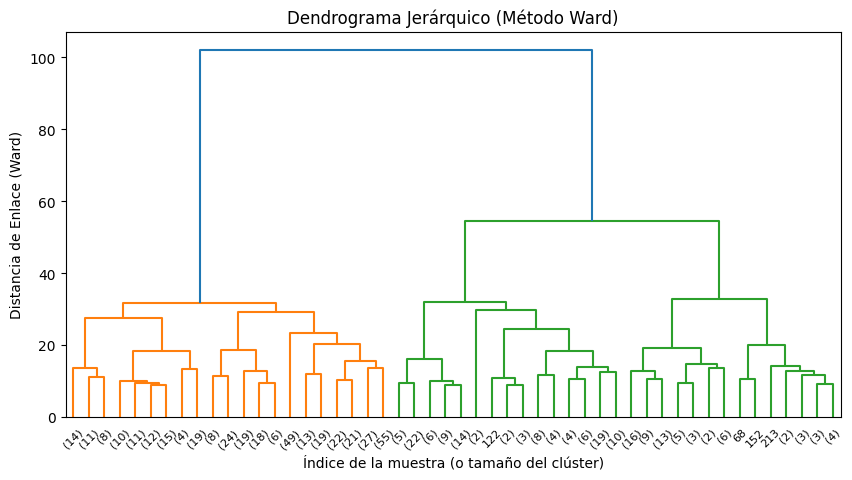

In [16]:
# CÁLCULO DEL DENDROGRAMA

# Calculamos la matriz de enlace usando el método de Ward
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 5))
plt.title("Dendrograma Jerárquico (Método Ward)")
plt.xlabel("Índice de la muestra (o tamaño del clúster)")
plt.ylabel("Distancia de Enlace (Ward)")
dendrogram(Z, truncate_mode="lastp", p=50, leaf_rotation=45)
plt.show()

Text(0, 0.5, 'Distancia de Combinación')

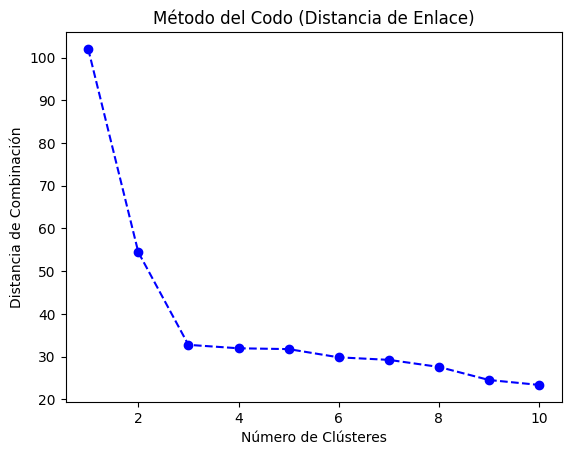

In [18]:
# Método del Codo para Clúster Jerárquico

# Tomamos las últimas distancias de combinación (los saltos más grandes)
last_distances = Z[-10:, 2]
# Invertimos el orden para simular la "inercia" decreciente a medida que aumentan los clústeres
num_clusters = np.arange(1, len(last_distances) + 1)
distances_rev = last_distances[::-1]

plt.plot(num_clusters, distances_rev, marker="o", linestyle="--", color="b")
plt.title("Método del Codo (Distancia de Enlace)")
plt.xlabel("Número de Clústeres")
plt.ylabel("Distancia de Combinación")

Text(0, 0.5, 'Componente Principal 2')

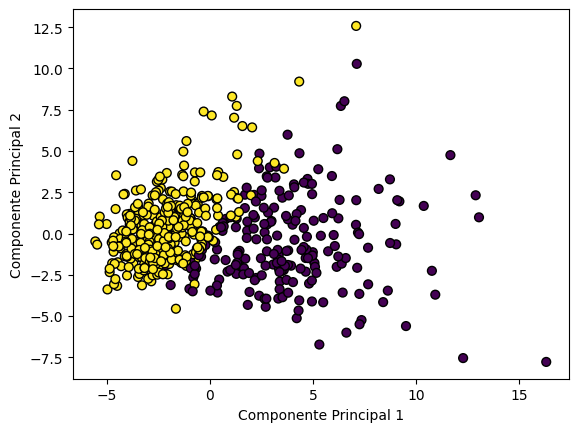

In [20]:
# REDUCCIÓN DE DIMENSIONALIDAD PARA VISUALIZACIÓN (PCA)

# Como el dataset tiene 30 características, usamos PCA a 2 componentes para poder graficarlo
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", edgecolor="k", s=40)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

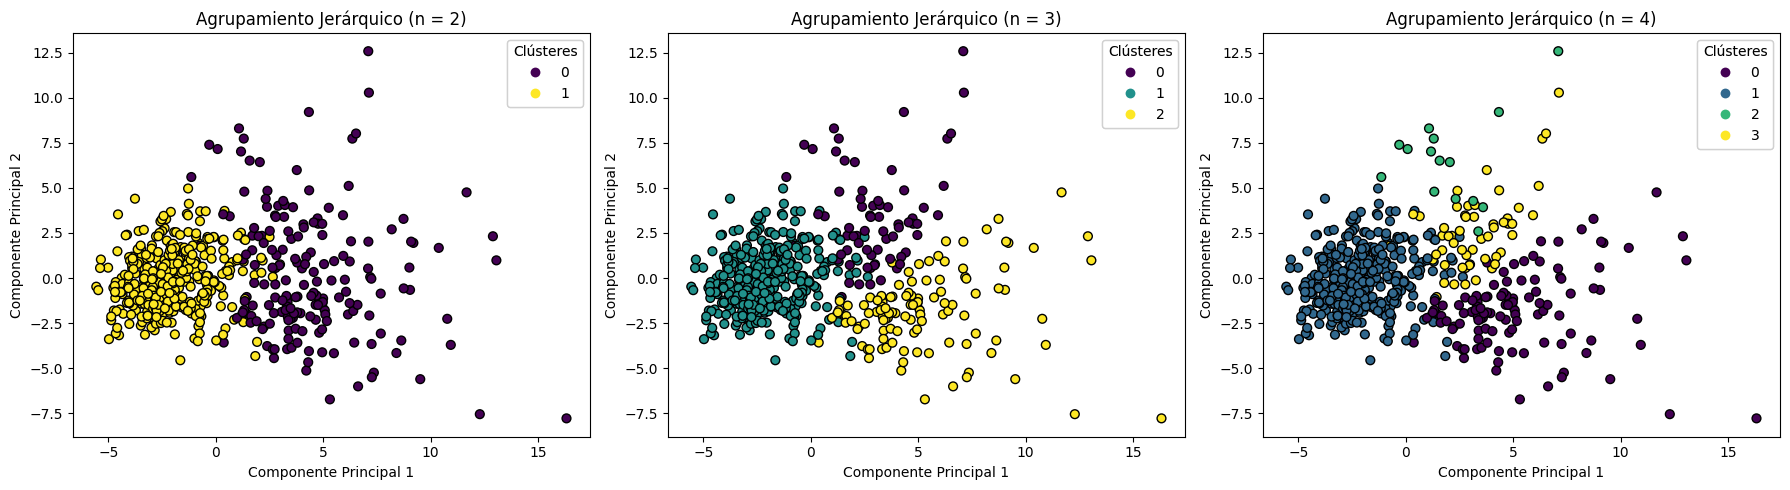

In [21]:
# AGRUPAMIENTO CON DIFERENTES VALORES DE N (Clústeres)

# Probaremos con 2 clústeres (sugerido por el dataset real), 3 y 4 clústeres.
valores_n = [2, 3, 4]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, n in enumerate(valores_n):
    # Aplicamos AgglomerativeClustering con el número de clústeres deseado
    cluster = AgglomerativeClustering(n_clusters=n, linkage="ward")
    cluster_labels = cluster.fit_predict(X_scaled)

    # Graficamos el resultado en el espacio de componentes principales (PCA)
    scatter = axes[i].scatter(
        X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", edgecolor="k", s=40
    )
    axes[i].set_title(f"Agrupamiento Jerárquico (n = {n})")
    axes[i].set_xlabel("Componente Principal 1")
    axes[i].set_ylabel("Componente Principal 2")

    # Añadimos una leyenda para identificar los clústeres
    legend = axes[i].legend(*scatter.legend_elements(), title="Clústeres")
    axes[i].add_artist(legend)

plt.tight_layout()
plt.show()